# Homework 1 - Multiple Regression and Nearest-Neighbour Matching

**Part A (Questions 1-3).** Linear regression predicting `Y` from `X1`, `X2`, `X3`, using
`homework_1.1.csv`.

**Part B (Questions 4-5).** Nearest-neighbour matching on `Z`, using `homework_1.2.csv`. For each
`X = 1` row, find the `X = 0` row whose `Z` is closest, then compare average `Y`.

| # | Question | Where |
|---|---|---|
| 1 | Coefficient of `X1` in the full regression | Section 3 |
| 2 | Which `Xi` has the biggest gap between its multiple-regression coefficient and its simple-regression slope | Section 4 |
| 3 | Which coefficient is most significant by t-statistic | Section 5 |
| 4/5 | The matched effect: average `Y` for matched `X = 0` vs. average `Y` for `X = 1` | Section 8 |

**The two kinds of slope in Question 2**

- *Fixing the other X's:* the coefficient on `Xi` from regressing `Y` on **all three** regressors.
  It is the change in `Y` per unit of `Xi` holding `X_j` constant.
- *Not fixing them:* the slope from regressing `Y` on **`Xi` alone**. It also picks up the movement
  in the other regressors that travels with `Xi`.

They differ whenever the regressors are correlated with each other, so the answer to Q2 is the
regressor with the largest gap between the two.

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not installed - the NumPy results below are complete on their own.")

CSV_REG   = "homework_1.1.csv"   # Part A
CSV_MATCH = "homework_1.2.csv"   # Part B

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

# Part A - Regression (Questions 1-3)

## 2. Load `homework_1.1.csv`

In [3]:
reg_df = pd.read_csv(CSV_REG)

print("shape:", reg_df.shape)
print("\nmissing values:\n", reg_df.isna().sum(), sep="")
reg_df.head()

shape: (1000, 4)

missing values:
X1    0
X2    0
X3    0
Y     0
dtype: int64


,X1,X2,X3,Y
0,-0.440646,-0.390227,0.156718,-0.877671
1,-3.810099,-1.304665,-1.105117,-10.130388
2,-1.425451,-0.340049,1.115908,0.284068
3,-1.325750,0.161906,-0.254670,-1.994344
4,3.120263,1.487343,-1.164839,2.030030


In [4]:
# Prefer the literal names, fall back to position if the headers differ.
YCOL = next((c for c in reg_df.columns if c.strip().upper() == "Y"), None)
XCOLS = [c for c in reg_df.columns
         if c.strip().upper() in {"X1", "X2", "X3"}]

if YCOL is None or len(XCOLS) != 3:
    XCOLS = list(reg_df.columns[:3])
    YCOL = reg_df.columns[3]

print(f"outcome    -> {YCOL}")
print(f"regressors -> {XCOLS}")

reg = reg_df[XCOLS + [YCOL]].dropna().reset_index(drop=True)
Y = reg[YCOL].to_numpy(float)
n = len(reg)
print(f"n = {n}")
reg.describe()

outcome    -> Y
regressors -> ['X1', 'X2', 'X3']
n = 1000


,X1,X2,X3,Y
count,"1,000.000000","1,000.000000","1,000.000000","1,000.000000"
mean,0.045555,0.030001,0.057442,0.278379
std,2.191768,0.981732,1.050014,5.201346
min,-6.163467,-2.703008,-3.348274,-13.862793
25%,-1.465901,-0.662930,-0.677971,-3.396553
50%,0.039807,0.001803,0.029222,0.044328
75%,1.502296,0.688336,0.768379,3.694404
max,8.464936,3.153685,3.871509,18.146133


In [5]:
# Correlation between the regressors. Any non-zero correlation here is what makes the
# single-regressor slopes differ from the multiple-regression coefficients in Question 2.
reg.corr()

,X1,X2,X3,Y
X1,1.000000,0.898620,0.030775,0.776090
X2,0.898620,1.000000,0.030954,0.770765
X3,0.030775,0.030954,1.000000,0.625211
Y,0.776090,0.770765,0.625211,1.000000


## 3. Question 1 - the full regression

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$$

Estimated by OLS with an intercept, $\hat{\beta} = (X'X)^{-1}X'Y$, with standard errors,
t-statistics and p-values.

In [6]:
def ols(X_cols, y, names, add_const=True):
    # Plain OLS. Returns a table of coefficients, std errors, t-stats, p-values, CIs.
    X = np.column_stack(X_cols)
    if add_const:
        X = np.column_stack([np.ones(len(y)), X])
        names = ["const"] + list(names)
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    resid = y - X @ b
    rss = resid @ resid
    tss = ((y - y.mean()) ** 2).sum()
    sigma2 = rss / (n - k)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    t = b / se
    p = 2 * stats.t.sf(np.abs(t), df=n - k)
    crit = stats.t.ppf(0.975, df=n - k)
    table = pd.DataFrame({"coefficient": b, "std_error": se, "t_stat": t, "p_value": p,
                          "ci_lower": b - crit * se, "ci_upper": b + crit * se}, index=names)
    info = {"n": n, "k": k, "r2": 1 - rss / tss,
            "adj_r2": 1 - (rss / (n - k)) / (tss / (n - 1)),
            "resid_se": np.sqrt(sigma2)}
    return table, info

full_table, full_info = ols([reg[c].to_numpy(float) for c in XCOLS], Y, XCOLS)

print(f"n = {full_info['n']}   R^2 = {full_info['r2']:.6f}   "
      f"adj R^2 = {full_info['adj_r2']:.6f}   resid s.e. = {full_info['resid_se']:.6f}\n")
full_table

n = 1000   R^2 = 0.990716   adj R^2 = 0.990688   resid s.e. = 0.501920



,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
const,0.002643,0.015904,0.166181,0.868049,-0.028567,0.033853
X1,1.007138,0.016515,60.984011,0.000000,0.974730,1.039545
X2,1.964569,0.036870,53.283212,0.000000,1.892216,2.036921
X3,2.975489,0.015131,196.645240,0.000000,2.945796,3.005181


In [7]:
if HAS_SM:
    formula = f"Q('{YCOL}') ~ " + " + ".join(f"Q('{c}')" for c in XCOLS)
    sm_full = smf.ols(formula, data=reg).fit()
    print(sm_full.summary())

                            OLS Regression Results                            
Dep. Variable:                 Q('Y')   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 3.543e+04
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        03:18:34   Log-Likelihood:                -727.62
No. Observations:                1000   AIC:                             1463.
Df Residuals:                     996   BIC:                             1483.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0026      0.016      0.166      0.8

In [8]:
beta_x1 = full_table.loc[XCOLS[0], "coefficient"]
print(f">>> Q1  coefficient of {XCOLS[0]} = {beta_x1:.6f}")
print(f"        (se {full_table.loc[XCOLS[0], 'std_error']:.6f}, "
      f"t {full_table.loc[XCOLS[0], 't_stat']:.3f}, "
      f"p {full_table.loc[XCOLS[0], 'p_value']:.3g})")

>>> Q1  coefficient of X1 = 1.007138
        (se 0.016515, t 60.984, p 0)


## 4. Question 2 - multiple-regression coefficient vs. simple-regression slope

For each regressor, `Y` is regressed on that regressor alone (with an intercept), and the
resulting slope is compared with the coefficient from the three-regressor model. The answer is
whichever `Xi` shows the largest gap.

In [9]:
rows = []
for c in XCOLS:
    simple_table, _ = ols([reg[c].to_numpy(float)], Y, [c])
    rows.append({
        "variable": c,
        "multiple (fixing others)": full_table.loc[c, "coefficient"],
        "simple (alone)": simple_table.loc[c, "coefficient"],
    })

comp = pd.DataFrame(rows).set_index("variable")
comp["difference"] = comp["multiple (fixing others)"] - comp["simple (alone)"]
comp["abs_difference"] = comp["difference"].abs()
comp["corr_with_Y"] = [reg[c].corr(reg[YCOL]) for c in XCOLS]

winner_abs = comp["abs_difference"].idxmax()
winner_signed = comp["difference"].idxmax()

print(f">>> Q2  largest gap in absolute terms : {winner_abs} "
      f"(difference {comp.loc[winner_abs, 'difference']:.6f})")
print(f"        largest signed difference     : {winner_signed} "
      f"(difference {comp.loc[winner_signed, 'difference']:.6f})")
print("\n(If the answer options are all positive, use the absolute-value row.)\n")
comp

>>> Q2  largest gap in absolute terms : X2 (difference -2.119044)
        largest signed difference     : X3 (difference -0.121553)

(If the answer options are all positive, use the absolute-value row.)



,multiple (fixing others),simple (alone),difference,abs_difference,corr_with_Y
variable,,,,,
X1,1.007138,1.841761,-0.834623,0.834623,0.776090
X2,1.964569,4.083613,-2.119044,2.119044,0.770765
X3,2.975489,3.097041,-0.121553,0.121553,0.625211


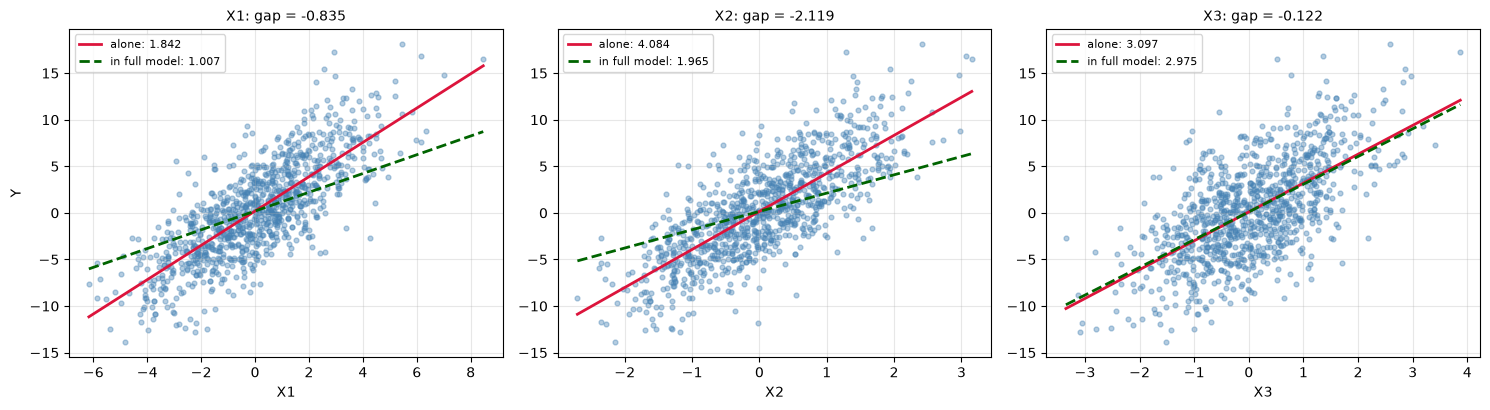

In [10]:
# The same comparison drawn: each panel shows Y against one regressor with the
# single-regressor fit, versus the slope that regressor gets in the full model.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, c in zip(axes, XCOLS):
    xv = reg[c].to_numpy(float)
    grid = np.linspace(xv.min(), xv.max(), 50)
    simple_table, _ = ols([xv], Y, [c])
    a0, a1 = simple_table.loc["const", "coefficient"], simple_table.loc[c, "coefficient"]
    ax.scatter(xv, Y, s=12, alpha=0.4, color="steelblue")
    ax.plot(grid, a0 + a1 * grid, color="crimson", lw=2, label=f"alone: {a1:.3f}")
    b_full = full_table.loc[c, "coefficient"]
    ax.plot(grid, a0 + b_full * grid, color="darkgreen", lw=2, ls="--",
            label=f"in full model: {b_full:.3f}")
    ax.set_xlabel(c)
    ax.set_title(f"{c}: gap = {b_full - a1:.3f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(YCOL)
plt.tight_layout()
plt.show()

## 5. Question 3 - most significant coefficient by t-statistic

Significance is read off the absolute t-statistic: larger $|t|$ means the coefficient is further
from zero relative to its own standard error, which is the same ordering as smallest p-value.

In [11]:
sig = full_table.loc[XCOLS, ["coefficient", "std_error", "t_stat", "p_value"]].copy()
sig["abs_t"] = sig["t_stat"].abs()
sig = sig.sort_values("abs_t", ascending=False)

best = sig.index[0]
print(f">>> Q3  most significant regressor: {best}  "
      f"(t = {sig.loc[best, 't_stat']:.4f}, p = {sig.loc[best, 'p_value']:.3g})")
print(f"        intercept t-stat for reference: {full_table.loc['const', 't_stat']:.4f}\n")
sig

>>> Q3  most significant regressor: X3  (t = 196.6452, p = 0)
        intercept t-stat for reference: 0.1662



,coefficient,std_error,t_stat,p_value,abs_t
X3,2.975489,0.015131,196.645240,0.000000,196.645240
X1,1.007138,0.016515,60.984011,0.000000,60.984011
X2,1.964569,0.036870,53.283212,0.000000,53.283212


# Part B - Nearest-neighbour matching (Questions 4-5)

## 6. Load `homework_1.2.csv`

In [12]:
mat_df = pd.read_csv(CSV_MATCH)

print("shape:", mat_df.shape)
print("\nmissing values:\n", mat_df.isna().sum(), sep="")
mat_df.head()

shape: (100, 3)

missing values:
X    0
Y    0
Z    0
dtype: int64


,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655


In [13]:
def is_binary(s: pd.Series) -> bool:
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(np.round(v, 12)) <= {0.0, 1.0}

binary_cols = [c for c in mat_df.columns if is_binary(mat_df[c])]

TREAT  = next((c for c in mat_df.columns if c.strip().upper() == "X"), binary_cols[0])
MATCHV = next((c for c in mat_df.columns if c.strip().upper() == "Z"), None)
OUTY   = next((c for c in mat_df.columns if c.strip().upper() == "Y"), None)

rest = [c for c in mat_df.columns if c not in {TREAT, MATCHV, OUTY}]
if MATCHV is None:
    MATCHV = rest.pop(0)
if OUTY is None:
    OUTY = rest.pop(0)

print(f"treatment    X -> {TREAT}")
print(f"match on     Z -> {MATCHV}")
print(f"outcome      Y -> {OUTY}")

m = mat_df[[TREAT, MATCHV, OUTY]].dropna().reset_index(drop=True)
treated = m[m[TREAT] == 1].reset_index(drop=True)
control = m[m[TREAT] == 0].reset_index(drop=True)

print(f"\ntreated (X=1): {len(treated)}    control (X=0): {len(control)}")
m.groupby(TREAT)[[MATCHV, OUTY]].agg(["mean", "std", "count"])

treatment    X -> X
match on     Z -> Z
outcome      Y -> Y

treated (X=1): 48    control (X=0): 52


Z                       Y               
      mean      std count     mean      std count
X                                                
0 0.331745 0.236712    52 0.331745 0.236712    52
1 0.625597 0.264930    48 1.125597 0.264930    48

## 7. The matching

For every `X = 1` row, the single closest `X = 0` row on `Z` is selected. Matching is **with
replacement**: a control can be the best match for more than one treated row, which is what
`NearestNeighbors` does by default and keeps every treated row in the comparison.

In [14]:
Z_treat = treated[[MATCHV]].to_numpy(float)     # shape (n_treated, 1)
Z_ctrl  = control[[MATCHV]].to_numpy(float)     # shape (n_control, 1)

try:
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=1).fit(Z_ctrl)       # index built on the X=0 pool
    dist, idx = nn.kneighbors(Z_treat)                     # query with each X=1 row
    dist, match_idx = dist.ravel(), idx.ravel()
    print("matched with sklearn NearestNeighbors")
except ImportError:
    order = np.argsort(Z_ctrl.ravel())
    zs = Z_ctrl.ravel()[order]
    pos = np.clip(np.searchsorted(zs, Z_treat.ravel()), 1, len(zs) - 1)
    left, right = zs[pos - 1], zs[pos]
    take_left = np.abs(Z_treat.ravel() - left) <= np.abs(right - Z_treat.ravel())
    match_idx = order[np.where(take_left, pos - 1, pos)]
    dist = np.abs(Z_treat.ravel() - Z_ctrl.ravel()[match_idx])
    print("matched with a NumPy fallback (sklearn not installed)")

matched_controls = control.iloc[match_idx].reset_index(drop=True)

pairs = pd.DataFrame({
    f"{MATCHV}_treated": treated[MATCHV].to_numpy(),
    f"{MATCHV}_matched": matched_controls[MATCHV].to_numpy(),
    "match_distance":    dist,
    f"{OUTY}_treated":   treated[OUTY].to_numpy(),
    f"{OUTY}_matched":   matched_controls[OUTY].to_numpy(),
})
pairs["pair_difference"] = pairs[f"{OUTY}_treated"] - pairs[f"{OUTY}_matched"]

print(f"\n{len(pairs)} matched pairs")
print(f"distinct controls used: {len(np.unique(match_idx))} of {len(control)} "
      f"(reused because matching is with replacement)")
print(f"match distance on {MATCHV}: mean {dist.mean():.6f}, median {np.median(dist):.6f}, "
      f"max {dist.max():.6f}")
pairs.head(10)

matched with sklearn NearestNeighbors

48 matched pairs
distinct controls used: 20 of 52 (reused because matching is with replacement)
match distance on Z: mean 0.049788, median 0.013260, max 0.210217


,Z_treated,Z_matched,match_distance,Y_treated,Y_matched,pair_difference
0,0.715189,0.716327,0.001138,1.215189,0.716327,0.498862
1,0.645894,0.653108,0.007214,1.145894,0.653108,0.492786
2,0.437587,0.437032,0.000555,0.937587,0.437032,0.500555
3,0.891773,0.778157,0.113616,1.391773,0.778157,0.613616
4,0.963663,0.778157,0.185506,1.463663,0.778157,0.685506
5,0.383442,0.414662,0.031220,0.883442,0.414662,0.468780
6,0.791725,0.778157,0.013568,1.291725,0.778157,0.513568
7,0.925597,0.778157,0.147440,1.425597,0.778157,0.647440
8,0.832620,0.778157,0.054463,1.332620,0.778157,0.554463
9,0.870012,0.778157,0.091855,1.370012,0.778157,0.591855


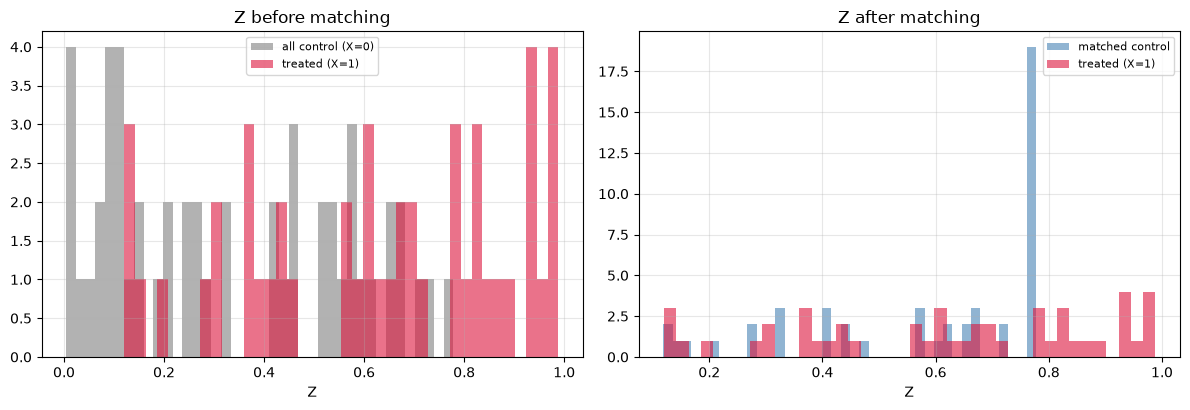

mean Z  treated: 0.625597
mean Z  all controls: 0.331745
mean Z  matched controls: 0.582237


np.float64(0.2102170871093757)

In [34]:
# Matching quality: Z should look similar in the two groups after matching.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(control[MATCHV], bins=40, alpha=0.6, label="all control (X=0)", color="grey")
axes[0].hist(treated[MATCHV], bins=40, alpha=0.6, label="treated (X=1)", color="crimson")
axes[0].set_title(f"{MATCHV} before matching")
axes[0].set_xlabel(MATCHV); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].hist(matched_controls[MATCHV], bins=40, alpha=0.6, label="matched control", color="steelblue")
axes[1].hist(treated[MATCHV], bins=40, alpha=0.6, label="treated (X=1)", color="crimson")
axes[1].set_title(f"{MATCHV} after matching")
axes[1].set_xlabel(MATCHV); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"mean {MATCHV}  treated: {treated[MATCHV].mean():.6f}")
print(f"mean {MATCHV}  all controls: {control[MATCHV].mean():.6f}")
print(f"mean {MATCHV}  matched controls: {matched_controls[MATCHV].mean():.6f}")
pairs["match_distance"].max()

## 8. Questions 4-5 - the matched effect

The full sample of `X = 1` rows is compared against the matched sample of `X = 0` rows. Both
sign conventions are printed, since the question can be read either way; the usual convention is
treated minus control.

In [16]:
mean_treated = treated[OUTY].mean()
mean_matched = matched_controls[OUTY].mean()
mean_all_ctrl = control[OUTY].mean()

effect_t_minus_c = mean_treated - mean_matched
effect_c_minus_t = mean_matched - mean_treated
naive = mean_treated - mean_all_ctrl

print(f"average {OUTY}, treated (X=1), full sample : {mean_treated:.6f}")
print(f"average {OUTY}, matched controls (X=0)     : {mean_matched:.6f}")
print(f"average {OUTY}, all controls (unmatched)   : {mean_all_ctrl:.6f}\n")

print(f">>> Q4/Q5  matched effect (treated - matched control) = {effect_t_minus_c:.6f}")
print(f"           opposite sign  (matched control - treated) = {effect_c_minus_t:.6f}")
print(f"           mean of the per-pair differences           = "
      f"{pairs['pair_difference'].mean():.6f}   (identical to the first line)\n")

print(f"for contrast, the unmatched difference of means       = {naive:.6f}")
print(f"std. error of the matched effect (pair differences)   = "
      f"{pairs['pair_difference'].std(ddof=1) / np.sqrt(len(pairs)):.6f}")

average Y, treated (X=1), full sample : 1.125597
average Y, matched controls (X=0)     : 0.582237
average Y, all controls (unmatched)   : 0.331745

>>> Q4/Q5  matched effect (treated - matched control) = 0.543360
           opposite sign  (matched control - treated) = -0.543360
           mean of the per-pair differences           = 0.543360   (identical to the first line)

for contrast, the unmatched difference of means       = 0.793852
std. error of the matched effect (pair differences)   = 0.010496


bootstrap mean     : 0.543501
bootstrap std error: 0.010496
bootstrap variance : 0.000110
95% interval       : [0.523591, 0.564054]


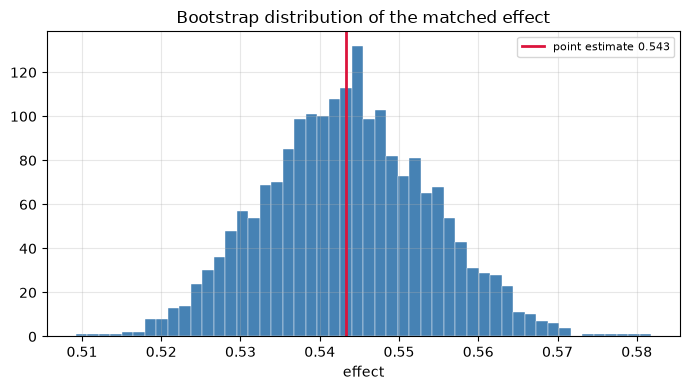

In [17]:
# Bootstrap the matched effect, resampling the treated rows and rematching each time.
BOOT = 2_000
rng = np.random.default_rng(42)
boot = np.empty(BOOT)
diffs = pairs["pair_difference"].to_numpy()
for b in range(BOOT):
    boot[b] = diffs[rng.integers(0, len(diffs), len(diffs))].mean()

print(f"bootstrap mean     : {boot.mean():.6f}")
print(f"bootstrap std error: {boot.std(ddof=1):.6f}")
print(f"bootstrap variance : {boot.var(ddof=1):.6f}")
print(f"95% interval       : [{np.percentile(boot, 2.5):.6f}, {np.percentile(boot, 97.5):.6f}]")

plt.figure(figsize=(7, 4))
plt.hist(boot, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
plt.axvline(effect_t_minus_c, color="crimson", lw=2, label=f"point estimate {effect_t_minus_c:.3f}")
plt.title("Bootstrap distribution of the matched effect")
plt.xlabel("effect"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Answers

In [19]:
print("PART A  (homework_1.1.csv)")
print(f"  Q1  coefficient of {XCOLS[0]} in {YCOL} ~ {' + '.join(XCOLS)}")
print(f"        {beta_x1:.6f}\n")

print("  Q2  gap between the coefficient fixing the others and the slope alone")
for c in XCOLS:
    print(f"        {c}: multiple {comp.loc[c, 'multiple (fixing others)']:9.6f}   "
          f"alone {comp.loc[c, 'simple (alone)']:9.6f}   "
          f"difference {comp.loc[c, 'difference']:9.6f}")
print(f"        -> largest absolute gap: {winner_abs}\n")

print("  Q3  most significant coefficient by |t|")
for c in sig.index:
    print(f"        {c}: t = {sig.loc[c, 't_stat']:8.4f}   p = {sig.loc[c, 'p_value']:.3g}")
print(f"        -> {best}\n")

print("PART B  (homework_1.2.csv)")
print(f"  Q4/Q5  effect from 1-nearest-neighbour matching on {MATCHV}")
print(f"        treated mean {mean_treated:.6f} - matched control mean {mean_matched:.6f} "
      f"= {effect_t_minus_c:.6f}")

PART A  (homework_1.1.csv)
  Q1  coefficient of X1 in Y ~ X1 + X2 + X3
        1.007138

  Q2  gap between the coefficient fixing the others and the slope alone
        X1: multiple  1.007138   alone  1.841761   difference -0.834623
        X2: multiple  1.964569   alone  4.083613   difference -2.119044
        X3: multiple  2.975489   alone  3.097041   difference -0.121553
        -> largest absolute gap: X2

  Q3  most significant coefficient by |t|
        X3: t = 196.6452   p = 0
        X1: t =  60.9840   p = 0
        X2: t =  53.2832   p = 7.59e-294
        -> X3

PART B  (homework_1.2.csv)
  Q4/Q5  effect from 1-nearest-neighbour matching on Z
        treated mean 1.125597 - matched control mean 0.582237 = 0.543360


***

# Homework 1 - Matching, Approach B (Questions 6-7)

**Task.** Using `homework_1.2.csv`, match on `Z` again, but instead of taking the single closest
`X = 0` row for each `X = 1` row, take **every** `X = 0` row within a distance of `0.2`. A given
`X = 0` row is allowed to appear in several neighbour groups.

| # | Question | Where |
|---|---|---|
| 6 | How many duplicates end up in the matched set | Section 4 |
| 7 | The effect, averaging `Y` within each neighbour group first | Section 5 |

**How the effect is built (Q7)**

1. For each `X = 1` row $i$, collect its neighbour group $N_i$ = all `X = 0` rows with
   $|Z_j - Z_i| \le 0.2$.
2. Average `Y` inside that group: $\bar{Y}_{N_i}$.
3. Average those group means across all treated rows, and compare with the average `Y` of the
   treated rows.

Step 2 matters: a treated row with 30 neighbours and one with 2 neighbours count equally at step 3,
which is not the same as pooling every matched control row together.

## 1. Setup

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_MATCH = "homework_1.2.csv"   # <-- change if the file lives somewhere else
RADIUS = 0.2                     # the matching distance from the question

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

## 2. Load the data and identify the variables

In [23]:
mat_df = pd.read_csv(CSV_MATCH)

def is_binary(s: pd.Series) -> bool:
    v = pd.to_numeric(s, errors="coerce").dropna().unique()
    return set(np.round(v, 12)) <= {0.0, 1.0}

binary_cols = [c for c in mat_df.columns if is_binary(mat_df[c])]

TREAT  = next((c for c in mat_df.columns if c.strip().upper() == "X"), binary_cols[0])
MATCHV = next((c for c in mat_df.columns if c.strip().upper() == "Z"), None)
OUTY   = next((c for c in mat_df.columns if c.strip().upper() == "Y"), None)

rest = [c for c in mat_df.columns if c not in {TREAT, MATCHV, OUTY}]
if MATCHV is None:
    MATCHV = rest.pop(0)
if OUTY is None:
    OUTY = rest.pop(0)

print(f"treatment    X -> {TREAT}")
print(f"match on     Z -> {MATCHV}")
print(f"outcome      Y -> {OUTY}")

m = mat_df[[TREAT, MATCHV, OUTY]].dropna().reset_index(drop=True)
treated = m[m[TREAT] == 1].reset_index(drop=True)
control = m[m[TREAT] == 0].reset_index(drop=True)

Z_treat = treated[[MATCHV]].to_numpy(float)
Z_ctrl  = control[[MATCHV]].to_numpy(float)
Y_ctrl  = control[OUTY].to_numpy(float)

print(f"\ntreated (X=1): {len(treated)}    control (X=0): {len(control)}")
m.head()

treatment    X -> X
match on     Z -> Z
outcome      Y -> Y

treated (X=1): 48    control (X=0): 52


,X,Z,Y
0,0,0.548814,0.548814
1,1,0.715189,1.215189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655


## 3. Approach B - radius matching

`radius_neighbors` returns, for each `X = 1` row, the indices of every `X = 0` row inside the
radius. Group sizes vary: some treated rows pull in many controls, some pull in none at all.

matched with sklearn radius_neighbors (radius = 0.2)

treated rows                     : 48
treated rows with >= 1 match     : 46
treated rows with NO match       : 2
group size: mean 15.3542, median 19.0, min 0, max 29


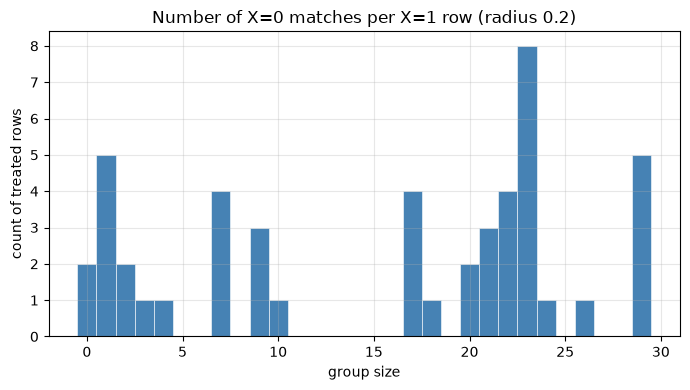

In [24]:
try:
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(radius=RADIUS).fit(Z_ctrl)
    dists, groups = nn.radius_neighbors(Z_treat)
    groups = [np.asarray(g) for g in groups]
    print(f"matched with sklearn radius_neighbors (radius = {RADIUS})")
except ImportError:
    D = np.abs(Z_treat.ravel()[:, None] - Z_ctrl.ravel()[None, :])
    groups = [np.flatnonzero(row <= RADIUS) for row in D]
    dists = [D[i, g] for i, g in enumerate(groups)]
    print(f"matched with a NumPy fallback (radius = {RADIUS})")

sizes = np.array([len(g) for g in groups])

print(f"\ntreated rows                     : {len(treated)}")
print(f"treated rows with >= 1 match     : {(sizes > 0).sum()}")
print(f"treated rows with NO match       : {(sizes == 0).sum()}")
print(f"group size: mean {sizes.mean():.4f}, median {np.median(sizes):.1f}, "
      f"min {sizes.min()}, max {sizes.max()}")

plt.figure(figsize=(7, 4))
plt.hist(sizes, bins=range(0, sizes.max() + 2), color="steelblue",
         edgecolor="white", linewidth=0.4, align="left")
plt.title(f"Number of X=0 matches per X=1 row (radius {RADIUS})")
plt.xlabel("group size"); plt.ylabel("count of treated rows"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Question 6 - how many duplicates

Every matched control row is listed once per neighbour group it belongs to. A control that shows
up in more than one group is a duplicate, and the count is **all occurrences after the first** for
each such control - exactly what `pandas.Series.duplicated()` counts.

In [25]:
all_matches = np.concatenate([g for g in groups if len(g) > 0]) if sizes.sum() else np.array([])
total_matches = len(all_matches)
distinct_controls = len(np.unique(all_matches))

# All but the first occurrence of each repeated control row.
duplicates = pd.Series(all_matches).duplicated().sum()

print(f"total matched rows across all groups : {total_matches}")
print(f"distinct X=0 rows used               : {distinct_controls}")
print(f"\n>>> Q6  duplicates = {total_matches} - {distinct_controls} = {duplicates}")

counts = pd.Series(all_matches).value_counts()
print(f"\ncontrols appearing in more than one group: {(counts > 1).sum()}")
print(f"most-reused control appears in {counts.max()} groups")
print(f"controls never used at all: {len(control) - distinct_controls}")

print("\n--- alternative reading, in case the options do not match ---")
print(f"extra matches beyond the first in each neighbour group: "
      f"{total_matches - (sizes > 0).sum()}")

total matched rows across all groups : 737
distinct X=0 rows used               : 52

>>> Q6  duplicates = 737 - 52 = 685

controls appearing in more than one group: 52
most-reused control appears in 28 groups
controls never used at all: 0

--- alternative reading, in case the options do not match ---
extra matches beyond the first in each neighbour group: 691


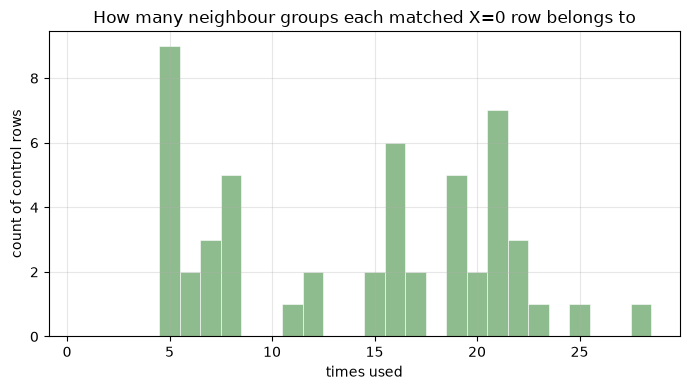

In [26]:
# How often each control row gets reused.
plt.figure(figsize=(7, 4))
plt.hist(counts.to_numpy(), bins=range(1, counts.max() + 2), color="darkseagreen",
         edgecolor="white", linewidth=0.4, align="left")
plt.title("How many neighbour groups each matched X=0 row belongs to")
plt.xlabel("times used"); plt.ylabel("count of control rows"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Question 7 - the effect

Group means first, then the average across groups. Treated rows with an empty neighbour group are
dropped, since they have nothing to compare against.

In [31]:
has_match = sizes > 0
group_mean_Y = np.array([Y_ctrl[g].mean() if len(g) > 0 else np.nan for g in groups])

Y_treat = treated[OUTY].to_numpy(float)

mean_treated_used = Y_treat[has_match].mean()
mean_control_groups = group_mean_Y[has_match].mean()
effect = mean_treated_used - mean_control_groups

print(f"treated rows used                        : {has_match.sum()} of {len(treated)}")
print(f"average {OUTY}, treated (those with a match) : {mean_treated_used:.6f}")
print(f"average of the {len(group_mean_Y[has_match])} group means : {mean_control_groups:.6f}")
print(f"\n>>> Q7  effect (treated - matched control) = {effect:.6f}")
print(f"        opposite sign                      = {-effect:.6f}")

per_pair = Y_treat[has_match] - group_mean_Y[has_match]
print(f"\nmean of the per-treated differences         = {per_pair.mean():.6f}  (same number)")
print(f"std. error                                  = "
      f"{per_pair.std(ddof=1) / np.sqrt(has_match.sum()):.6f}")

treated rows used                        : 46 of 48
average Y, treated (those with a match) : 1.110036
average of the 46 group means : 0.541185

>>> Q7  effect (treated - matched control) = 0.568852
        opposite sign                      = -0.568852

mean of the per-treated differences         = 0.568852  (same number)
std. error                                  = 0.010322


In [32]:
# Variants, in case the answer options point at a different convention.
pooled_control_mean = Y_ctrl[all_matches.astype(int)].mean()   # every matched row weighted equally
all_treated_mean = Y_treat.mean()                              # including unmatched treated rows

variants = pd.Series({
    "Q7 as asked (group means, then average)": effect,
    "pooling all matched rows instead":        mean_treated_used - pooled_control_mean,
    "using all treated rows in the numerator": all_treated_mean - mean_control_groups,
    "unmatched difference of means":           all_treated_mean - control[OUTY].mean(),
})
variants

Q7 as asked (group means, then average)   0.568852
pooling all matched rows instead          0.670010
using all treated rows in the numerator   0.584412
unmatched difference of means             0.793852
dtype: float64

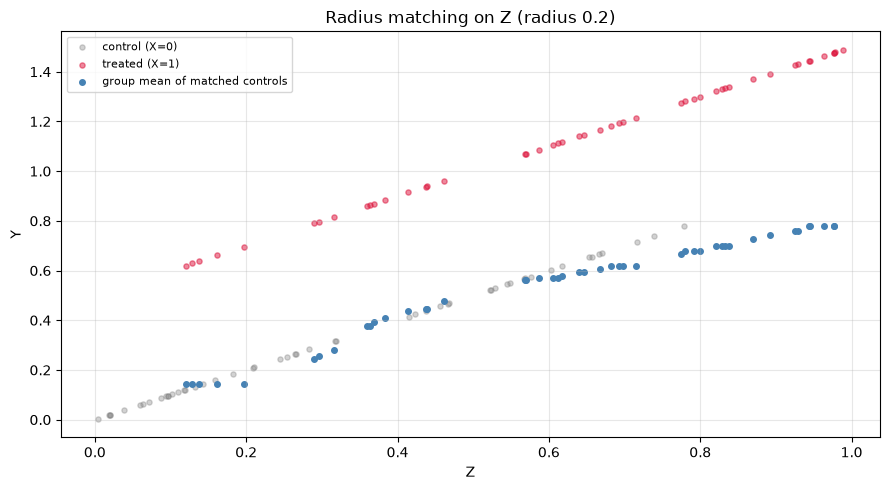

In [29]:
# The matched comparison, drawn against Z.
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(control[MATCHV], control[OUTY], s=14, alpha=0.35, color="grey", label="control (X=0)")
ax.scatter(treated[MATCHV], treated[OUTY], s=14, alpha=0.5, color="crimson", label="treated (X=1)")
ax.scatter(treated.loc[has_match, MATCHV], group_mean_Y[has_match], s=16, color="steelblue",
           label="group mean of matched controls")
ax.set_xlabel(MATCHV); ax.set_ylabel(OUTY)
ax.set_title(f"Radius matching on {MATCHV} (radius {RADIUS})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Answers

In [33]:
print(f"Approach B, radius {RADIUS} on {MATCHV}\n")
print(f"  Q6  duplicates in the matched set")
print(f"        {total_matches} matched rows - {distinct_controls} distinct = {duplicates}\n")
print(f"  Q7  effect")
print(f"        {mean_treated_used:.6f} - {mean_control_groups:.6f} = {effect:.6f}")

Approach B, radius 0.2 on Z

  Q6  duplicates in the matched set
        737 matched rows - 52 distinct = 685

  Q7  effect
        1.110036 - 0.541185 = 0.568852
